In [8]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from classlist import (
    Linear,
    BatchNorm1d,
    Tanh,
    FlattenConsecutive,
    Embedding,
    Sequential,
)

In [9]:
words = open("names.txt", "r").read().splitlines()
chars = sorted(list(set("".join(words))))
stoi = {".": 0}
stoi.update({s: i + 1 for i, s in enumerate(chars)})
itos = {i: s for s, i in stoi.items()}
vocab_size = len(stoi)

block_size = 8


def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y


n = len(words)
train_size = 0.8
dev_size = 0.1
test_size = 0.1
n1 = int(n * train_size)
n2 = int(n * (train_size + dev_size))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [27]:
n_embd = 24
n_hidden = 128
batch_size = 32
g = torch.Generator().manual_seed(42)

layers = [
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2),
    Linear(n_embd * 2, n_hidden, bias=False, nonlinearity="tanh", generator=g),
    BatchNorm1d(n_hidden, momentum=0.1),
    Tanh(),
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False, nonlinearity="tanh", generator=g),
    BatchNorm1d(n_hidden, momentum=0.1),
    Tanh(),
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False, nonlinearity="tanh", generator=g),
    BatchNorm1d(n_hidden, momentum=0.1),
    Tanh(),
    Linear(n_hidden, vocab_size, generator=g),
]
model = Sequential(layers=layers)
for p in model.parameters():
    p.requires_grad = True

In [28]:
max_steps = 50000
lossi = []
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)
    if i % 100 == 0:
        lossi.append(loss)
    for p in model.parameters():
        p.grad = None

    loss.backward()
    lr = 0.1 if i < 40000 else 0.01
    weight_decay = 1e-3
    for p in model.parameters():
        p.data -= lr * (p.grad + weight_decay * p.data)

1.4959876537322998

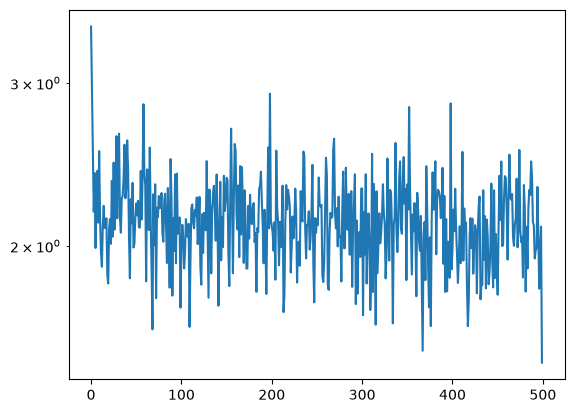

In [29]:
lossi = [loss.item() for loss in lossi]
plt.plot(lossi)
plt.yscale("log")
lossi[-1]

In [30]:
@torch.no_grad()
def split_loss(split):
    x, y = {"train": (Xtr, Ytr), "dev": (Xdev, Ydev), "test": (Xte, Yte)}[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())


for layer in model.layers:
    layer.training = False  # 切到eval模式,BatchNorm用running stats而不是batch统计量

split_loss("train")
split_loss("dev")

train 2.0211751461029053
dev 2.277113199234009


In [ ]:
for layer in model.layers:
    layer.training = False

g_sample = torch.Generator().manual_seed(2147483647 + 20)

for _ in range(20):
    out = []
    context = [0] * block_size  # 用0(即'.')初始化context
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g_sample).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print("".join(itos[i] for i in out))

rryel.
jarsyn.
licrisa.
marick.
shoie.
khocra.
aldola.
tosever.
keoselo.
teah.
aris.
wradoli.
alaisandro.
zailara.
torianna.
vaewa.
kamaraie.
adrayots.
camalane.
avindhera.
